<a href="https://colab.research.google.com/github/ExTc-aShiSh/Introduction-to-AI/blob/main/Monkey_banana_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   MONKEY-BANANA PROBLEM  —  BFS State-Space Search
  Initial: monkey=LEFT  box=RIGHT  on_box=False
  Goal   : grab banana hanging at MIDDLE (ceiling)

  Solution found in 5 steps!

  Step  0: Walk: left -> right                 | monkey=left   box=right  on_box=False has_banana=False
  Step  1: Push box: right -> middle           | monkey=right  box=right  on_box=False has_banana=False
  Step  2: Climb UP at middle                  | monkey=middle box=middle on_box=False has_banana=False
  Step  3: GRAB BANANA!                        | monkey=middle box=middle on_box=True  has_banana=False
  Step  4: GOAL REACHED!                       | monkey=middle box=middle on_box=True  has_banana=True


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/monkey_banana_solution.png'

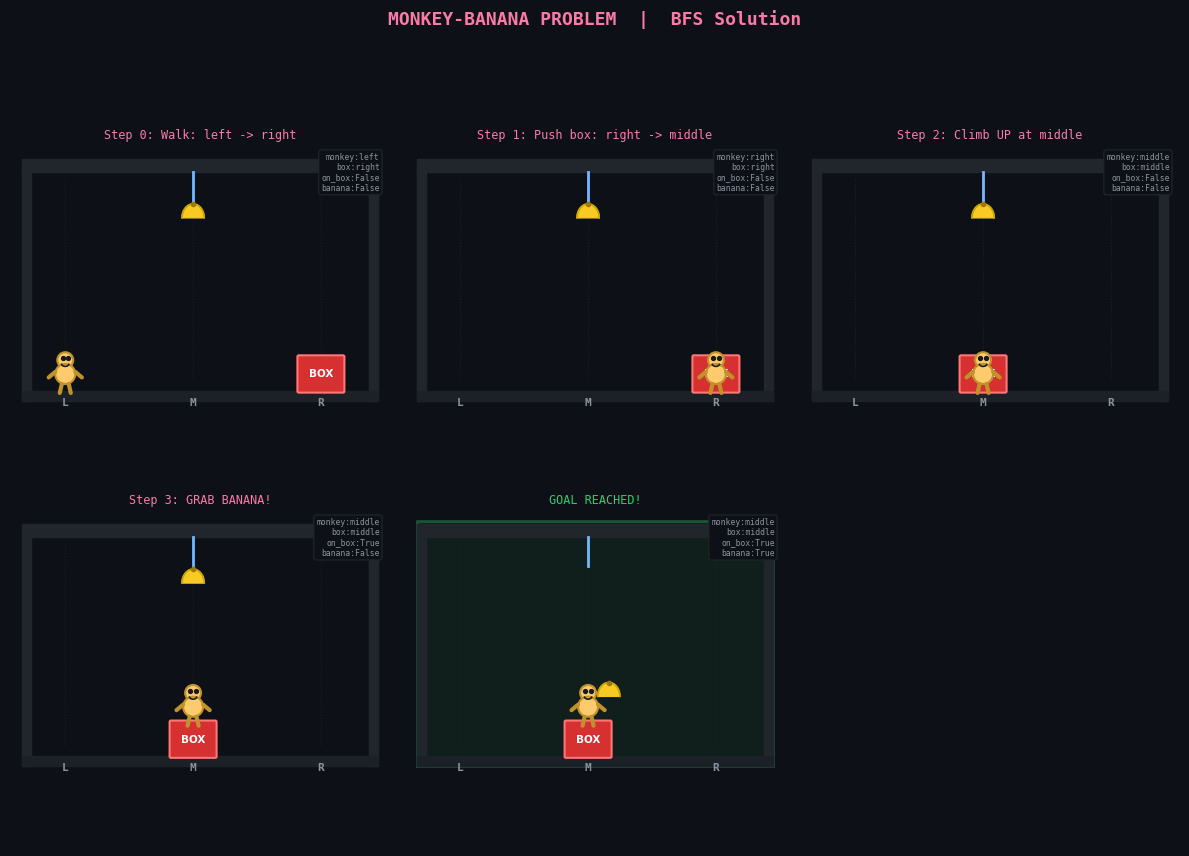

In [7]:
"""
Monkey-Banana Problem — Classic AI Lab Experiment
Solved using BFS State-Space Search with Matplotlib Visualization
"""

from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BANANA_POS = 'middle'
POSITIONS  = ['left', 'middle', 'right']
POS_X      = {'left': 0.8, 'middle': 2.65, 'right': 4.5}

INITIAL_STATE = ('left',   'right',  False, False)

def is_goal(state):
    return state[3]

def get_successors(state):
    monkey_pos, box_pos, on_box, has_banana = state
    successors = []
    if has_banana:
        return successors
    if not on_box:
        for pos in POSITIONS:
            if pos != monkey_pos:
                successors.append((f"Walk: {monkey_pos} -> {pos}",
                                   (pos, box_pos, False, False)))
        if monkey_pos == box_pos:
            for pos in POSITIONS:
                if pos != monkey_pos:
                    successors.append((f"Push box: {monkey_pos} -> {pos}",
                                       (pos, pos, False, False)))
            successors.append((f"Climb UP at {monkey_pos}",
                                (monkey_pos, box_pos, True, False)))
    else:
        successors.append((f"Climb DOWN at {monkey_pos}",
                            (monkey_pos, box_pos, False, False)))
        if monkey_pos == BANANA_POS and box_pos == BANANA_POS:
            successors.append(("GRAB BANANA!",
                                (monkey_pos, box_pos, True, True)))
    return successors

def bfs_solve():
    queue   = deque([(INITIAL_STATE, [])])
    visited = {INITIAL_STATE}
    while queue:
        state, path = queue.popleft()
        if is_goal(state):
            return path + [("GOAL REACHED!", state)]
        for action, nxt in get_successors(state):
            if nxt not in visited:
                visited.add(nxt)
                queue.append((nxt, path + [(action, state)]))
    return None

# ── Palette ──────────────────────────────────
BG      = '#0d1117'
PANEL   = '#161b22'
WALL    = '#21262d'
FLOOR_C = '#1c2128'
BOX_C   = '#d63031'
MONK_C  = '#fdcb6e'
BAN_C   = '#f9ca24'
ROPE_C  = '#74b9ff'
TXT     = '#e6edf3'
SUB     = '#8b949e'
ACC     = '#2ecc71'
TITLE_C = '#fd79a8'
GOAL_HL = '#1a3a28'

def draw_monkey(ax, cx, cy, zorder=8):
    ax.add_patch(plt.Circle((cx, cy+0.13), 0.115, color=MONK_C, ec='#c0922a', lw=1.5, zorder=zorder))
    ax.add_patch(plt.Circle((cx, cy-0.07), 0.145, color=MONK_C, ec='#c0922a', lw=1.5, zorder=zorder))
    ax.plot([cx-0.038, cx+0.038], [cy+0.155, cy+0.155], 'o', color='#1a1a1a', ms=2.8, zorder=zorder+1)
    theta = np.linspace(np.pi*1.1, np.pi*1.9, 20)
    ax.plot(cx+0.055*np.cos(theta), cy+0.08+0.04*np.sin(theta),
            color='#1a1a1a', lw=1.2, zorder=zorder+1)
    for dx, ddx, ybase in [(-0.145, -0.24, cy-0.04), (0.145, 0.24, cy-0.04)]:
        ax.plot([cx+dx, cx+ddx], [ybase, ybase-0.08],
                color='#c0922a', lw=3, solid_capstyle='round', zorder=zorder)
    for dx, ybase in [(-0.05, cy-0.215), (0.05, cy-0.215)]:
        ax.plot([cx+dx, cx+dx*1.6], [ybase, ybase-0.13],
                color='#c0922a', lw=3, solid_capstyle='round', zorder=zorder)

def draw_banana(ax, cx, cy, zorder=5):
    t  = np.linspace(0, np.pi, 50)
    bx = cx + 0.16*np.cos(t)
    by = cy + 0.20*np.sin(t) - 0.10
    ax.fill(bx, by, color=BAN_C, zorder=zorder)
    ax.plot(bx, by, color='#c8a800', lw=1.3, zorder=zorder+1)
    ax.plot(cx, cy+0.10, 'o', color='#a07800', ms=3, zorder=zorder+1)

def draw_scene(ax, state, step_num, action):
    monkey_pos, box_pos, on_box, has_banana = state
    ax.set_facecolor(PANEL)
    ax.set_xlim(0, 5.5)
    ax.set_ylim(-0.65, 3.2)
    ax.set_aspect('equal')
    ax.axis('off')

    # walls / ceiling / floor
    ax.add_patch(plt.Rectangle((0.18, 2.82), 5.14, 0.18, color=WALL, zorder=1))
    ax.add_patch(plt.Rectangle((0.18, -0.5), 0.12, 3.35, color=WALL, zorder=1))
    ax.add_patch(plt.Rectangle((5.20, -0.5), 0.12, 3.35, color=WALL, zorder=1))
    ax.add_patch(plt.Rectangle((0.18, -0.50), 5.14, 0.14, color=FLOOR_C, zorder=2))

    # grid lines & labels
    for p in POSITIONS:
        px = POS_X[p]
        ax.axvline(px, color=WALL, lw=0.8, ls=':', ymin=0.12, ymax=0.88, zorder=1, alpha=0.7)
        ax.text(px, -0.60, p.upper()[0], ha='center', va='bottom',
                fontsize=8, color=SUB, fontfamily='monospace', fontweight='bold')

    # rope + banana
    bx = POS_X[BANANA_POS]
    ax.plot([bx, bx], [2.82, 2.40], color=ROPE_C, lw=2.0, zorder=3)
    if not has_banana:
        draw_banana(ax, bx, 2.25, zorder=4)

    # box
    bpx = POS_X[box_pos]
    ax.add_patch(mpatches.FancyBboxPatch((bpx-0.32, -0.36), 0.64, 0.50,
                  boxstyle='round,pad=0.02', color=BOX_C, ec='#ff7675',
                  lw=1.5, zorder=4))
    ax.text(bpx, -0.11, 'BOX', ha='center', va='center',
            fontsize=7.5, color='white', fontweight='bold', zorder=5)

    # monkey
    mx = POS_X[monkey_pos]
    my = 0.43 if on_box else -0.04
    draw_monkey(ax, mx, my, zorder=8)

    # banana held
    if has_banana:
        draw_banana(ax, mx+0.30, my+0.18 if on_box else my+0.15, zorder=9)

    # title
    color = ACC if has_banana else TITLE_C
    label = f"Step {step_num}: " + action if not has_banana else action
    ax.set_title(label, fontsize=8.5, color=color, pad=5,
                 fontfamily='monospace')

    # state badge
    badge = (f"monkey:{monkey_pos}\n"
             f"box:{box_pos}\n"
             f"on_box:{on_box}\n"
             f"banana:{has_banana}")
    ax.text(5.35, 3.10, badge, ha='right', va='top',
            fontsize=5.8, color=SUB, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', fc=BG, ec=WALL, lw=0.8))

    if has_banana:
        ax.add_patch(plt.Rectangle((0.18, -0.5), 5.14, 3.55,
                     color=GOAL_HL, alpha=0.35, zorder=0,
                     lw=2.0, ec=ACC))


def main():
    print("=" * 60)
    print("   MONKEY-BANANA PROBLEM  —  BFS State-Space Search")
    print("=" * 60)
    print("  Initial: monkey=LEFT  box=RIGHT  on_box=False")
    print("  Goal   : grab banana hanging at MIDDLE (ceiling)")
    print("=" * 60)

    solution = bfs_solve()
    if not solution:
        print("  No solution found.")
        return

    print(f"\n  Solution found in {len(solution)} steps!\n")
    for i, (action, state) in enumerate(solution):
        mp, bp, ob, hb = state
        print(f"  Step {i:2d}: {action:<35} "
              f"| monkey={mp:6s} box={bp:6s} on_box={str(ob):5s} has_banana={hb}")

    n    = len(solution)
    cols = 3
    rows = (n + cols - 1) // cols

    fig = plt.figure(figsize=(cols*4.0, rows*4.0 + 0.6), facecolor=BG)
    fig.suptitle("MONKEY-BANANA PROBLEM  |  BFS Solution",
                 fontsize=13, color=TITLE_C, fontweight='bold',
                 fontfamily='monospace', y=0.99)

    for idx, (action, state) in enumerate(solution):
        ax = fig.add_subplot(rows, cols, idx+1)
        draw_scene(ax, state, idx, action)

    for idx in range(n, rows*cols):
        ax = fig.add_subplot(rows, cols, idx+1)
        ax.set_facecolor(BG)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out = '/mnt/user-data/outputs/monkey_banana_solution.png'
    plt.savefig(out, dpi=155, bbox_inches='tight', facecolor=BG)
    print(f"\n  Visualization saved -> {out}")
    plt.show()

if __name__ == '__main__':
    main()